# Classification Models

## The Heart Disease Dataset

### Dataset Description

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Fetch Heart Disease dataset from UCI ──────────────────────────────────
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/heart-disease/processed.cleveland.data"
)
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]
df_raw = pd.read_csv(url, names=col_names, na_values="?")

# Binarise target: 0 = no disease, 1 = disease (original values 1–4)
df_raw["target"] = (df_raw["target"] > 0).astype(int)

print(f"Shape            : {df_raw.shape}")
print(f"Missing values   : {df_raw.isna().sum().sum()} total "
      f"({df_raw.isna().sum()[df_raw.isna().sum() > 0].to_dict()})")
print(f"\nClass balance    :")
print(df_raw["target"].value_counts(normalize=True).rename({0: "No disease", 1: "Disease"}))
print(f"\nFeature dtypes   :\n{df_raw.dtypes.value_counts()}")

Shape            : (303, 14)
Missing values   : 6 total ({'ca': 4, 'thal': 2})

Class balance    :
target
No disease    0.541254
Disease       0.458746
Name: proportion, dtype: float64

Feature dtypes   :
float64    13
int64       1
Name: count, dtype: int64


### Feature Description

In [2]:
feature_info = pd.DataFrame({
    "Feature": col_names[:-1],
    "Description": [
        "Age (years)",
        "Sex (1=male, 0=female)",
        "Chest pain type (0–3)",
        "Resting blood pressure (mmHg)",
        "Serum cholesterol (mg/dl)",
        "Fasting blood sugar > 120 mg/dl (1=True)",
        "Resting ECG results (0–2)",
        "Maximum heart rate achieved",
        "Exercise-induced angina (1=yes)",
        "ST depression induced by exercise",
        "Slope of peak exercise ST segment (0–2)",
        "Number of major vessels coloured by fluoroscopy (0–3)",
        "Thalassemia type (1=normal, 2=fixed defect, 3=reversible)"
    ],
    "Type": ["Continuous", "Binary", "Categorical", "Continuous",
             "Continuous", "Binary", "Categorical", "Continuous",
             "Binary", "Continuous", "Categorical", "Categorical", "Categorical"]
})
print(feature_info.to_string(index=False))

 Feature                                               Description        Type
     age                                               Age (years)  Continuous
     sex                                    Sex (1=male, 0=female)      Binary
      cp                                     Chest pain type (0–3) Categorical
trestbps                             Resting blood pressure (mmHg)  Continuous
    chol                                 Serum cholesterol (mg/dl)  Continuous
     fbs                  Fasting blood sugar > 120 mg/dl (1=True)      Binary
 restecg                                 Resting ECG results (0–2) Categorical
 thalach                               Maximum heart rate achieved  Continuous
   exang                           Exercise-induced angina (1=yes)      Binary
 oldpeak                         ST depression induced by exercise  Continuous
   slope                   Slope of peak exercise ST segment (0–2) Categorical
      ca     Number of major vessels coloured by flu

### Data Splitting and Preprocessing Setup

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              RocCurveDisplay)

# ── Feature matrix and response ───────────────────────────────────────────
X = df_raw.drop("target", axis=1)
y = df_raw["target"]

# ── Stratified 70/30 split ────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

print(f"Training set   : {X_tr.shape[0]} rows  "
      f"(positive rate: {y_tr.mean():.3f})")
print(f"Test set       : {X_te.shape[0]} rows  "
      f"(positive rate: {y_te.mean():.3f})")

# ── Stratified 10-fold CV object (reused throughout the chapter) ──────────
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

Training set   : 212 rows  (positive rate: 0.458)
Test set       : 91 rows  (positive rate: 0.462)


### Exploratory Visualisation

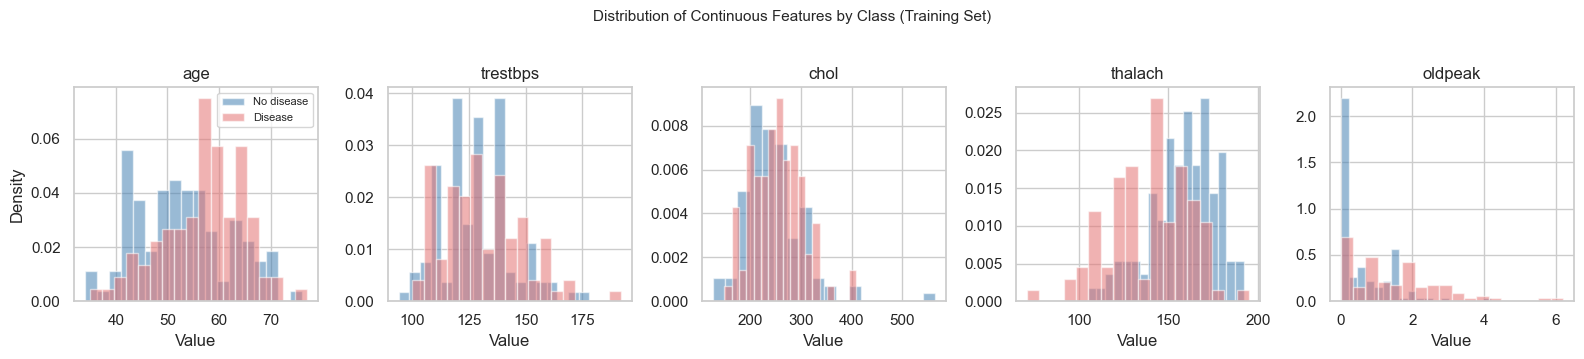

In [4]:
cont_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, len(cont_features), figsize=(16, 3.5))
for ax, feat in zip(axes, cont_features):
    for cls, label, color in zip([0, 1], ["No disease", "Disease"],
                                  ["steelblue", "#E57373"]):
        ax.hist(X_tr.loc[y_tr == cls, feat], bins=18,
                alpha=0.55, density=True, color=color, label=label)
    ax.set_title(feat)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density" if feat == "age" else "")
axes[0].legend(fontsize=8)

plt.suptitle("Distribution of Continuous Features by Class (Training Set)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## Logistic Regression — Machine Learning Perspective 

### Tuning the Regularisation Strength

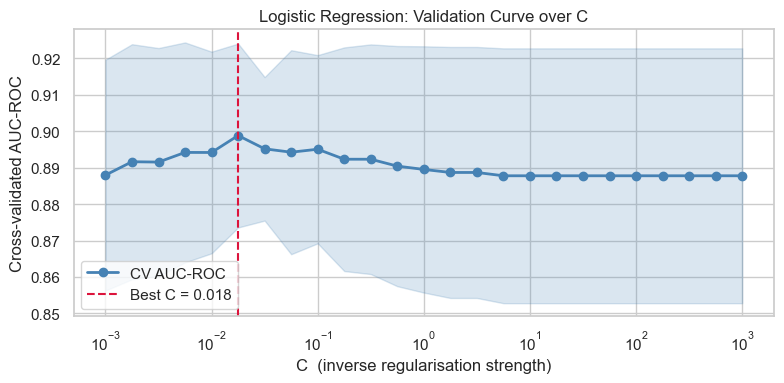

Best C          : 0.0178
Best CV AUC-ROC : 0.8988  ±  0.0252


In [5]:
from sklearn.linear_model import LogisticRegression

# ── Pipeline: impute → scale → logistic regression ────────────────────────
def make_lr_pipe(C=1.0, penalty="l2", solver="lbfgs"):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(
                        C=C, penalty=penalty, solver=solver,
                        max_iter=1000, random_state=RANDOM_SEED))
    ])

# ── Validation curve over C ────────────────────────────────────────────────
C_grid = np.logspace(-3, 3, 25)
cv_means, cv_stds = [], []

for C in C_grid:
    scores = cross_val_score(
        make_lr_pipe(C=C), X_tr, y_tr,
        cv=skf, scoring="roc_auc"
    )
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
best_C   = C_grid[np.argmax(cv_means)]

plt.figure(figsize=(8, 4))
plt.semilogx(C_grid, cv_means, "o-", color="steelblue", lw=2, label="CV AUC-ROC")
plt.fill_between(C_grid, cv_means - cv_stds, cv_means + cv_stds,
                 alpha=0.2, color="steelblue")
plt.axvline(best_C, color="crimson", linestyle="--", lw=1.5,
            label=f"Best C = {best_C:.3f}")
plt.xlabel("C  (inverse regularisation strength)")
plt.ylabel("Cross-validated AUC-ROC")
plt.title("Logistic Regression: Validation Curve over C")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ch11_lr_valcurve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best C          : {best_C:.4f}")
print(f"Best CV AUC-ROC : {cv_means.max():.4f}  ±  {cv_stds[np.argmax(cv_means)]:.4f}")

### Fitting the Final Logistic Regression Model

In [6]:
# ── Fit on full training set with best C ─────────────────────────────────
pipe_lr = make_lr_pipe(C=best_C)
pipe_lr.fit(X_tr, y_tr)

y_pred_lr    = pipe_lr.predict(X_te)
y_proba_lr   = pipe_lr.predict_proba(X_te)[:, 1]

acc_lr  = accuracy_score(y_te, y_pred_lr)
auc_lr  = roc_auc_score(y_te, y_proba_lr)

print("Logistic Regression — Test Set Performance")
print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  AUC-ROC   : {auc_lr:.4f}")
print(f"\n{classification_report(y_te, y_pred_lr, target_names=['No disease','Disease'])}")

Logistic Regression — Test Set Performance
  Accuracy  : 0.8571
  AUC-ROC   : 0.9349

              precision    recall  f1-score   support

  No disease       0.85      0.90      0.87        49
     Disease       0.87      0.81      0.84        42

    accuracy                           0.86        91
   macro avg       0.86      0.85      0.86        91
weighted avg       0.86      0.86      0.86        91



### Coefficient Interpretation

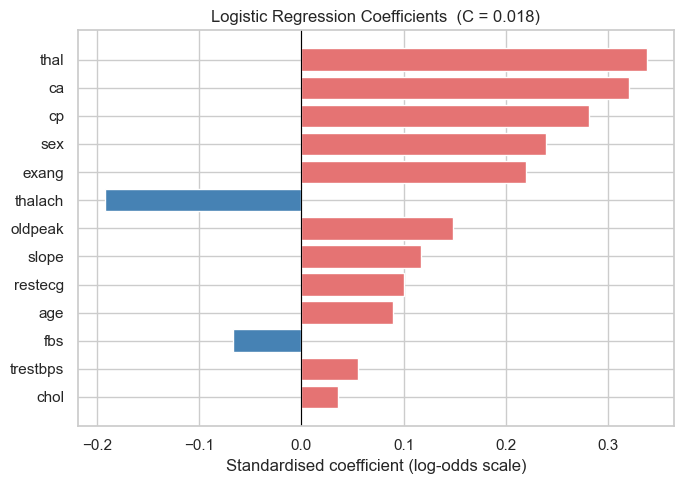

In [7]:
# ── Extract and plot standardised coefficients ────────────────────────────
coef = pipe_lr.named_steps["clf"].coef_[0]
feat_names = X.columns.tolist()

coef_df = pd.DataFrame({"feature": feat_names, "coef": coef})
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#E57373" if c > 0 else "steelblue" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardised coefficient (log-odds scale)")
ax.set_title(f"Logistic Regression Coefficients  (C = {best_C:.3f})")
plt.tight_layout()
plt.savefig(FIGURES / "ch11_lr_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

### Tuning $k$

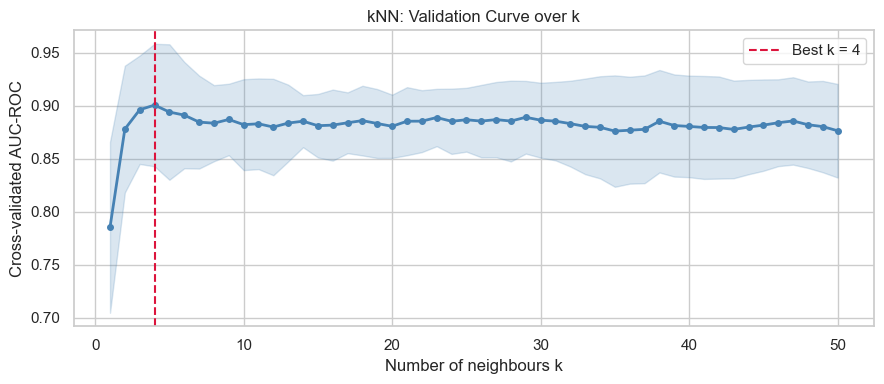

Best k          : 4
Best CV AUC-ROC : 0.9008  ±  0.0578


In [8]:
from sklearn.neighbors import KNeighborsClassifier

k_grid = list(range(1, 51))
cv_means_knn, cv_stds_knn = [], []

for k in k_grid:
    pipe_knn = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_tr, y_tr,
                             cv=skf, scoring="roc_auc")
    cv_means_knn.append(scores.mean())
    cv_stds_knn.append(scores.std())

cv_means_knn = np.array(cv_means_knn)
cv_stds_knn  = np.array(cv_stds_knn)
best_k       = k_grid[np.argmax(cv_means_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_grid, cv_means_knn, "o-", color="steelblue", lw=2, ms=4)
plt.fill_between(k_grid,
                 cv_means_knn - cv_stds_knn,
                 cv_means_knn + cv_stds_knn,
                 alpha=0.2, color="steelblue")
plt.axvline(best_k, color="crimson", linestyle="--", lw=1.5,
            label=f"Best k = {best_k}")
plt.xlabel("Number of neighbours k")
plt.ylabel("Cross-validated AUC-ROC")
plt.title("kNN: Validation Curve over k")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ch11_knn_valcurve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best k          : {best_k}")
print(f"Best CV AUC-ROC : {cv_means_knn.max():.4f}  ±  {cv_stds_knn[np.argmax(cv_means_knn)]:.4f}")

### Fitting the Final kNN Model

In [9]:
pipe_knn_best = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn_best.fit(X_tr, y_tr)

y_pred_knn  = pipe_knn_best.predict(X_te)
y_proba_knn = pipe_knn_best.predict_proba(X_te)[:, 1]

acc_knn = accuracy_score(y_te, y_pred_knn)
auc_knn = roc_auc_score(y_te, y_proba_knn)

print(f"kNN (k={best_k}) — Test Set Performance")
print(f"  Accuracy  : {acc_knn:.4f}")
print(f"  AUC-ROC   : {auc_knn:.4f}")
print(f"\n{classification_report(y_te, y_pred_knn, target_names=['No disease','Disease'])}")

kNN (k=4) — Test Set Performance
  Accuracy  : 0.8022
  AUC-ROC   : 0.8479

              precision    recall  f1-score   support

  No disease       0.79      0.86      0.82        49
     Disease       0.82      0.74      0.78        42

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91



### Why kNN Requires Feature Scaling

In [10]:
# ── Effect of scaling on kNN performance ──────────────────────────────────
pipe_knn_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     KNeighborsClassifier(n_neighbors=best_k))   # no scaler
])
scores_unscaled = cross_val_score(
    pipe_knn_unscaled, X_tr, y_tr, cv=skf, scoring="roc_auc"
)
scores_scaled = cross_val_score(
    pipe_knn_best, X_tr, y_tr, cv=skf, scoring="roc_auc"
)

print(f"kNN k={best_k} — CV AUC-ROC without scaling : "
      f"{scores_unscaled.mean():.4f} ± {scores_unscaled.std():.4f}")
print(f"kNN k={best_k} — CV AUC-ROC with scaling    : "
      f"{scores_scaled.mean():.4f} ± {scores_scaled.std():.4f}")

kNN k=4 — CV AUC-ROC without scaling : 0.6273 ± 0.0948
kNN k=4 — CV AUC-ROC with scaling    : 0.9008 ± 0.0578


## Decision Trees

### Controlling Tree Depth

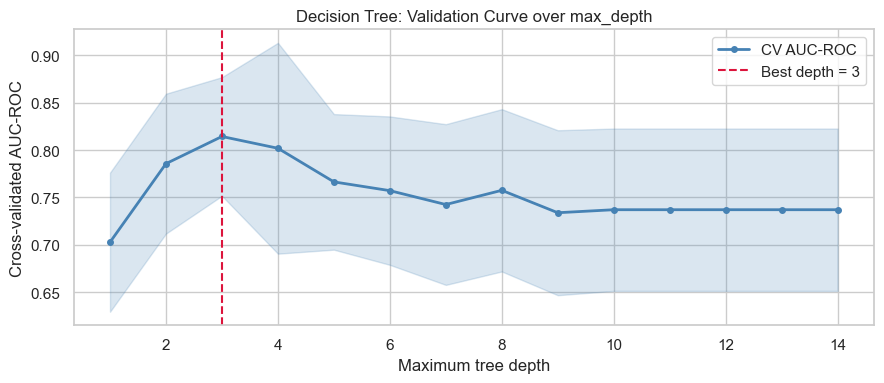

Best max_depth  : 3
Best CV AUC-ROC : 0.8143  ±  0.0626
Unpruned tree CV AUC-ROC : 0.7371 ± 0.0856


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

depth_grid = list(range(1, 15))
cv_means_dt, cv_stds_dt = [], []

for d in depth_grid:
    pipe_dt = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     DecisionTreeClassifier(
                        max_depth=d, random_state=RANDOM_SEED))
    ])
    scores = cross_val_score(pipe_dt, X_tr, y_tr,
                             cv=skf, scoring="roc_auc")
    cv_means_dt.append(scores.mean())
    cv_stds_dt.append(scores.std())

cv_means_dt = np.array(cv_means_dt)
cv_stds_dt  = np.array(cv_stds_dt)
best_depth  = depth_grid[np.argmax(cv_means_dt)]

# ── Also test unpruned tree ────────────────────────────────────────────────
pipe_dt_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     DecisionTreeClassifier(max_depth=None,
                                       random_state=RANDOM_SEED))
])
scores_full = cross_val_score(pipe_dt_full, X_tr, y_tr,
                              cv=skf, scoring="roc_auc")
train_score_full = cross_val_score(
    pipe_dt_full, X_tr, y_tr, cv=skf, scoring="roc_auc"
).mean()

plt.figure(figsize=(9, 4))
plt.plot(depth_grid, cv_means_dt, "o-", color="steelblue", lw=2, ms=4,
         label="CV AUC-ROC")
plt.fill_between(depth_grid,
                 cv_means_dt - cv_stds_dt,
                 cv_means_dt + cv_stds_dt,
                 alpha=0.2, color="steelblue")
plt.axvline(best_depth, color="crimson", linestyle="--", lw=1.5,
            label=f"Best depth = {best_depth}")
plt.xlabel("Maximum tree depth")
plt.ylabel("Cross-validated AUC-ROC")
plt.title("Decision Tree: Validation Curve over max_depth")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ch11_dt_valcurve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best max_depth  : {best_depth}")
print(f"Best CV AUC-ROC : {cv_means_dt.max():.4f}  ±  {cv_stds_dt[np.argmax(cv_means_dt)]:.4f}")
print(f"Unpruned tree CV AUC-ROC : {scores_full.mean():.4f} ± {scores_full.std():.4f}")

### Fitting the Final Decision Tree

In [12]:
pipe_dt_best = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     DecisionTreeClassifier(
                    max_depth=best_depth, random_state=RANDOM_SEED))
])
pipe_dt_best.fit(X_tr, y_tr)

y_pred_dt  = pipe_dt_best.predict(X_te)
y_proba_dt = pipe_dt_best.predict_proba(X_te)[:, 1]

acc_dt = accuracy_score(y_te, y_pred_dt)
auc_dt = roc_auc_score(y_te, y_proba_dt)

print(f"Decision Tree (depth={best_depth}) — Test Set Performance")
print(f"  Accuracy  : {acc_dt:.4f}")
print(f"  AUC-ROC   : {auc_dt:.4f}")
print(f"\n{classification_report(y_te, y_pred_dt, target_names=['No disease','Disease'])}")

Decision Tree (depth=3) — Test Set Performance
  Accuracy  : 0.7912
  AUC-ROC   : 0.8158

              precision    recall  f1-score   support

  No disease       0.79      0.84      0.81        49
     Disease       0.79      0.74      0.77        42

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



### Visualising the Decision Tree

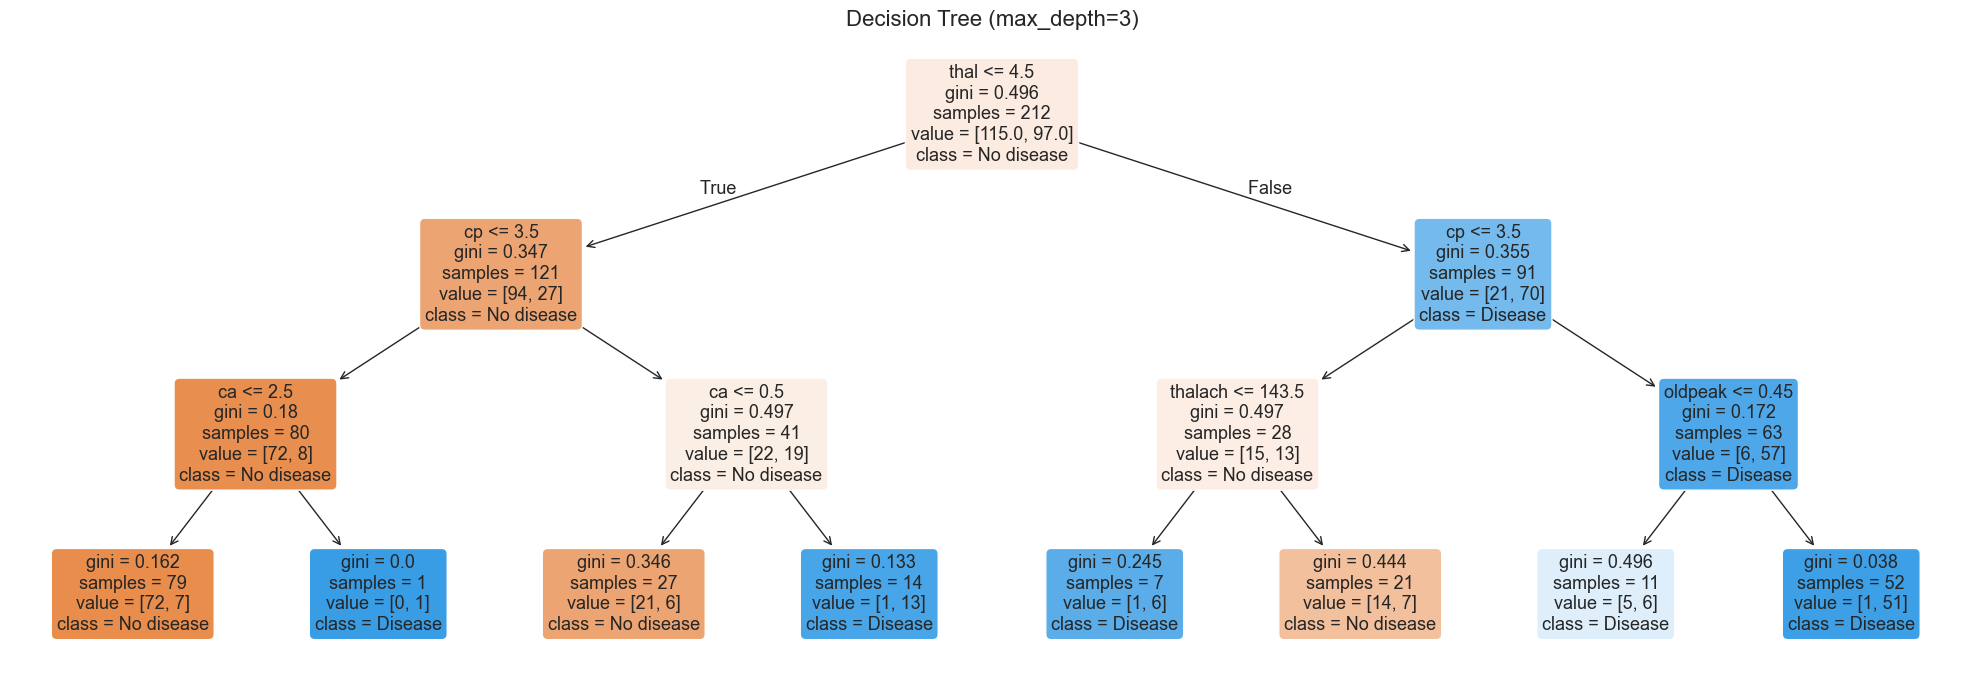

In [14]:
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    pipe_dt_best.named_steps["clf"],
    feature_names=X.columns.tolist(),
    class_names=["No disease", "Disease"],
    filled=True, rounded=True, fontsize=13, ax=ax,
    impurity=True, proportion=False
)
ax.set_title(f"Decision Tree (max_depth={best_depth})", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_dt_tree.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Importance

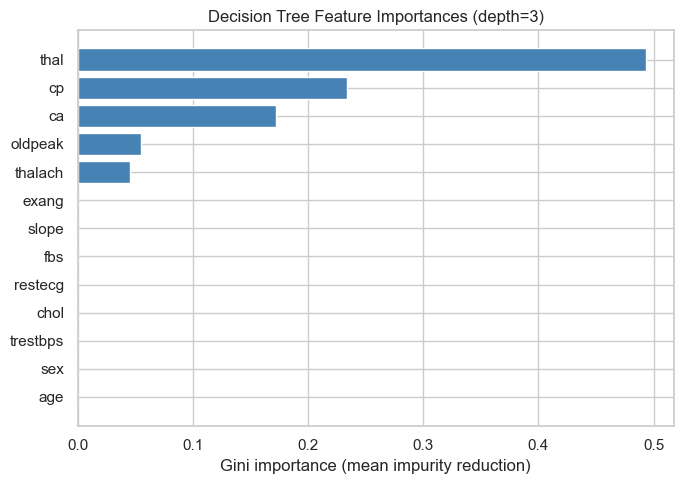

 feature  importance
    thal    0.493102
      cp    0.233710
      ca    0.172555
 oldpeak    0.054775
 thalach    0.045859
 restecg    0.000000
    chol    0.000000
trestbps    0.000000
     sex    0.000000
     age    0.000000
   exang    0.000000
     fbs    0.000000
   slope    0.000000


In [14]:
importances = pipe_dt_best.named_steps["clf"].feature_importances_
feat_imp_df = (pd.DataFrame({"feature": X.columns, "importance": importances})
               .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feat_imp_df["feature"], feat_imp_df["importance"],
        color="steelblue", edgecolor="white")
ax.set_xlabel("Gini importance (mean impurity reduction)")
ax.set_title(f"Decision Tree Feature Importances (depth={best_depth})")
plt.tight_layout()
plt.savefig(FIGURES / "ch11_dt_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(feat_imp_df.sort_values("importance", ascending=False).to_string(index=False))

## Support Vector Machines

### Tuning C and γ with Grid Search

In [15]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# ── Preprocessing pipeline shared by all SVM variants ─────────────────────
def make_svm_pipe(kernel="rbf", **svm_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     SVC(kernel=kernel, probability=True,
                        random_state=RANDOM_SEED, **svm_params))
    ])

# ── Grid search over C and γ (RBF kernel) ─────────────────────────────────
param_grid_rbf = {
    "clf__C":     [0.01, 0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

gs_rbf = GridSearchCV(
    make_svm_pipe(kernel="rbf"),
    param_grid_rbf,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)
gs_rbf.fit(X_tr, y_tr)

print("RBF-SVM Grid Search Results")
print(f"  Best parameters : {gs_rbf.best_params_}")
print(f"  Best CV AUC-ROC : {gs_rbf.best_score_:.4f}")

RBF-SVM Grid Search Results
  Best parameters : {'clf__C': 10, 'clf__gamma': 0.01}
  Best CV AUC-ROC : 0.9004


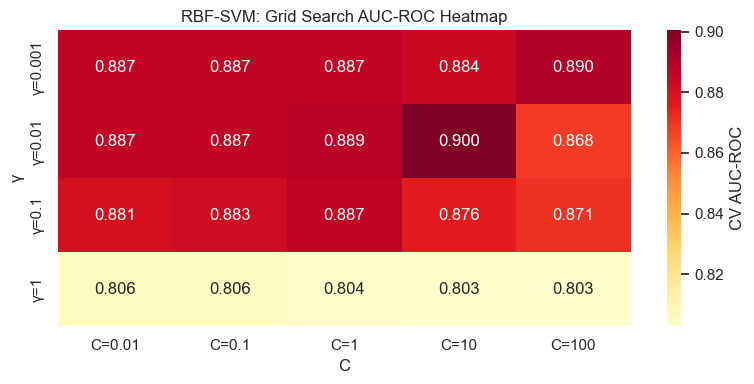

In [16]:
# ── Heatmap of CV AUC-ROC across the C-γ grid ─────────────────────────────
results_df = pd.DataFrame(gs_rbf.cv_results_)
# Filter rows where gamma is numeric for the heatmap
results_num = results_df[results_df["param_clf__gamma"] != "scale"].copy()
results_num["param_clf__gamma"] = results_num["param_clf__gamma"].astype(float)

pivot = results_num.pivot_table(
    index="param_clf__gamma",
    columns="param_clf__C",
    values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=[f"C={v}" for v in [0.01, 0.1, 1, 10, 100]],
            yticklabels=[f"γ={v}" for v in [0.001, 0.01, 0.1, 1]],
            ax=ax, cbar_kws={"label": "CV AUC-ROC"})
ax.set_title("RBF-SVM: Grid Search AUC-ROC Heatmap")
ax.set_xlabel("C")
ax.set_ylabel("γ")
plt.tight_layout()
plt.savefig(FIGURES / "ch11_svm_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparing Linear and RBF Kernels

In [17]:
# ── Linear SVM ────────────────────────────────────────────────────────────
param_grid_lin = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}

gs_lin = GridSearchCV(
    make_svm_pipe(kernel="linear"),
    param_grid_lin,
    cv=skf, scoring="roc_auc",
    n_jobs=-1, refit=True
)
gs_lin.fit(X_tr, y_tr)

print("Linear SVM Grid Search")
print(f"  Best C          : {gs_lin.best_params_['clf__C']}")
print(f"  Best CV AUC-ROC : {gs_lin.best_score_:.4f}")
print()
print("RBF SVM Grid Search")
print(f"  Best params     : {gs_rbf.best_params_}")
print(f"  Best CV AUC-ROC : {gs_rbf.best_score_:.4f}")

Linear SVM Grid Search
  Best C          : 0.01
  Best CV AUC-ROC : 0.8940

RBF SVM Grid Search
  Best params     : {'clf__C': 10, 'clf__gamma': 0.01}
  Best CV AUC-ROC : 0.9004


### Fitting the Final SVM Model

In [18]:
# ── Best model is the refitted RBF-SVM from grid search ───────────────────
y_pred_svm  = gs_rbf.predict(X_te)
y_proba_svm = gs_rbf.predict_proba(X_te)[:, 1]

acc_svm = accuracy_score(y_te, y_pred_svm)
auc_svm = roc_auc_score(y_te, y_proba_svm)

print(f"RBF-SVM — Test Set Performance")
print(f"  Accuracy  : {acc_svm:.4f}")
print(f"  AUC-ROC   : {auc_svm:.4f}")
print(f"\n{classification_report(y_te, y_pred_svm, target_names=['No disease','Disease'])}")

RBF-SVM — Test Set Performance
  Accuracy  : 0.8242
  AUC-ROC   : 0.9111

              precision    recall  f1-score   support

  No disease       0.84      0.84      0.84        49
     Disease       0.81      0.81      0.81        42

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



## Model Comparison and Selection

### ROC Curves

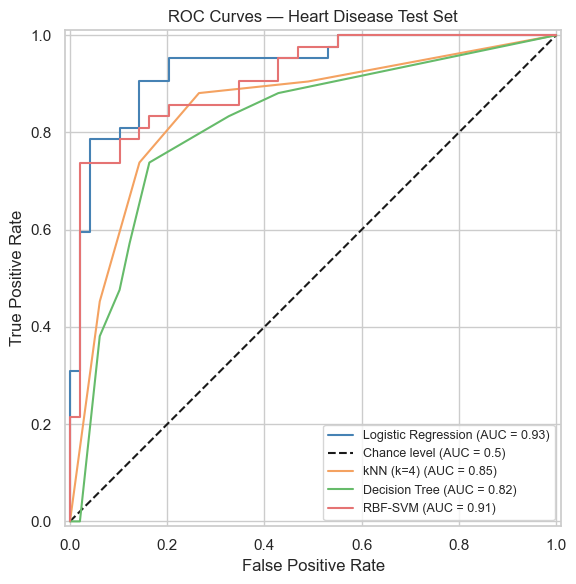

In [19]:
from sklearn.metrics import RocCurveDisplay, auc

fig, ax = plt.subplots(figsize=(7, 6))

models = {
    "Logistic Regression": (y_proba_lr, "steelblue"),
    "kNN (k=4)":          (y_proba_knn, "#F4A261"),
    "Decision Tree":       (y_proba_dt, "#66BB6A"),
    "RBF-SVM":             (y_proba_svm, "#E57373"),
}

for name, (proba, color) in models.items():
    RocCurveDisplay.from_predictions(
        y_te, proba, name=name, ax=ax,
        color=color, plot_chance_level=(name == "Logistic Regression")
    )

ax.set_title("ROC Curves — Heart Disease Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_roc.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrices

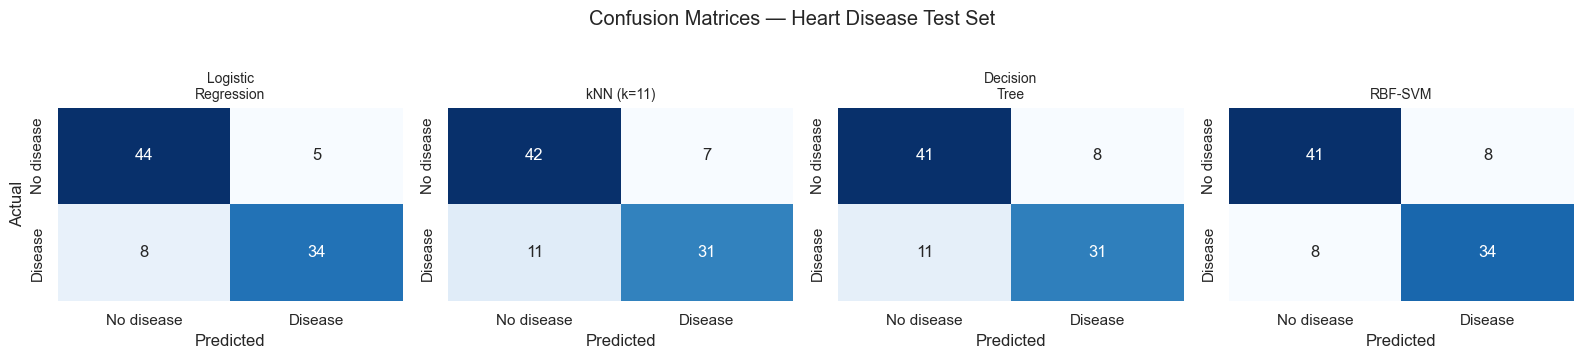

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
class_names = ["No disease", "Disease"]

for ax, (name, y_pred) in zip(axes, {
    "Logistic\nRegression": y_pred_lr,
    "kNN (k=11)":           y_pred_knn,
    "Decision\nTree":       y_pred_dt,
    "RBF-SVM":              y_pred_svm,
}.items()):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names, ax=ax,
                cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if name == "Logistic\nRegression" else "")

plt.suptitle("Confusion Matrices — Heart Disease Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_confmat.png", dpi=150, bbox_inches="tight")
plt.show()

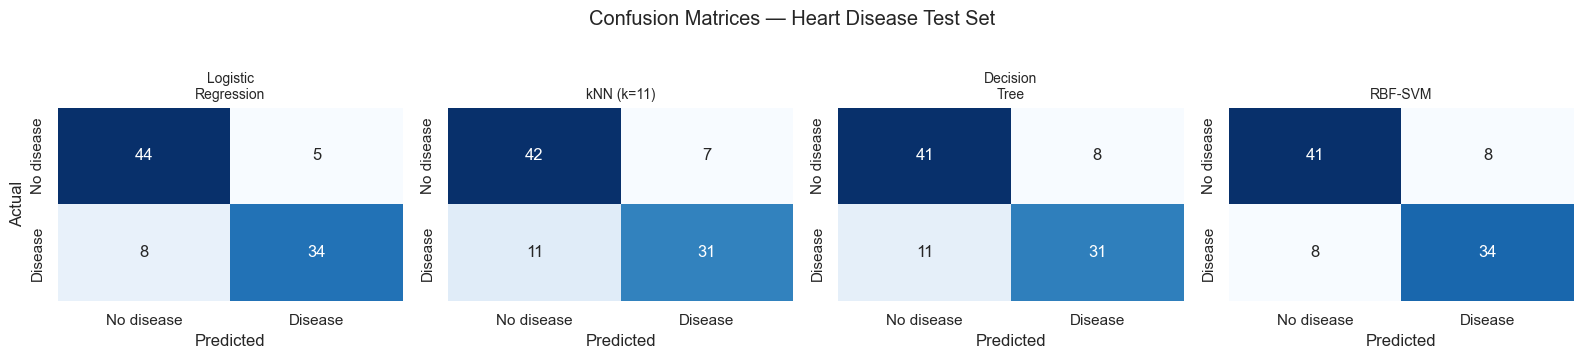

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
class_names = ["No disease", "Disease"]

for ax, (name, y_pred) in zip(axes, {
    "Logistic\nRegression": y_pred_lr,
    "kNN (k=11)":           y_pred_knn,
    "Decision\nTree":       y_pred_dt,
    "RBF-SVM":              y_pred_svm,
}.items()):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names, ax=ax,
                cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if name == "Logistic\nRegression" else "")

plt.suptitle("Confusion Matrices — Heart Disease Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch11_confmat.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
results_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "kNN (k=11)", "Decision Tree", "RBF-SVM"],
    "CV AUC-ROC": [
        cv_means.max(),
        cv_means_knn.max(),
        cv_means_dt.max(),
        gs_rbf.best_score_
    ],
    "Test Accuracy": [acc_lr, acc_knn, acc_dt, acc_svm],
    "Test AUC-ROC":  [auc_lr, auc_knn, auc_dt, auc_svm],
})
results_summary = results_summary.sort_values("Test AUC-ROC", ascending=False)

print(results_summary.to_string(index=False, float_format="{:.4f}".format))

              Model  CV AUC-ROC  Test Accuracy  Test AUC-ROC
Logistic Regression      0.8988         0.8571        0.9349
            RBF-SVM      0.9004         0.8242        0.9111
         kNN (k=11)      0.9008         0.8022        0.8479
      Decision Tree      0.8143         0.7912        0.8158


## A Complete Model Selection Workflow

In [23]:
def evaluate_pipeline(pipe, X_train, y_train, X_test, y_test,
                      cv, model_name="Model"):
    """
    Fit a pipeline on X_train, estimate performance via CV,
    evaluate on X_test, and return a summary dict.
    """
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                cv=cv, scoring="roc_auc")
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "model":        model_name,
        "cv_auc_mean":  cv_scores.mean(),
        "cv_auc_std":   cv_scores.std(),
        "test_acc":     accuracy_score(y_test, y_pred),
        "test_auc":     roc_auc_score(y_test, y_proba),
    }

# ── Collect results for all tuned models ─────────────────────────────────
from sklearn.model_selection import GridSearchCV

final_results = []

# Logistic Regression (best C from validation curve)
final_results.append(evaluate_pipeline(
    make_lr_pipe(C=best_C), X_tr, y_tr, X_te, y_te,
    skf, "Logistic Regression"
))

# kNN (best k)
final_results.append(evaluate_pipeline(
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     KNeighborsClassifier(n_neighbors=best_k))
    ]),
    X_tr, y_tr, X_te, y_te, skf, f"kNN (k={best_k})"
))

# Decision Tree (best depth)
final_results.append(evaluate_pipeline(
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     DecisionTreeClassifier(
                        max_depth=best_depth, random_state=RANDOM_SEED))
    ]),
    X_tr, y_tr, X_te, y_te, skf, f"Decision Tree (d={best_depth})"
))

# RBF-SVM (best params from grid search — already fitted)
final_results.append({
    "model":       "RBF-SVM",
    "cv_auc_mean": gs_rbf.best_score_,
    "cv_auc_std":  gs_rbf.cv_results_["std_test_score"][gs_rbf.best_index_],
    "test_acc":    acc_svm,
    "test_auc":    auc_svm,
})

res_df = (pd.DataFrame(final_results)
            .sort_values("test_auc", ascending=False))

print(res_df.to_string(index=False, float_format="{:.4f}".format))

              model  cv_auc_mean  cv_auc_std  test_acc  test_auc
Logistic Regression       0.8988      0.0252    0.8571    0.9349
            RBF-SVM       0.9004      0.0391    0.8242    0.9111
          kNN (k=4)       0.9008      0.0578    0.8022    0.8479
Decision Tree (d=3)       0.8143      0.0626    0.7912    0.8158
